In [1]:
from iqm.qiskit_iqm import IQMProvider
from fiqci.ems import FiQCIBackend
from qiskit import QuantumCircuit, transpile

url = None
quantum_computer = None

# Connect to an IQM quantum computer using the provider
if url is not None and quantum_computer is not None:
	provider = IQMProvider(url=url, quantum_computer=quantum_computer)
	backend = provider.get_backend()
else:
	# Or using a noisy simulator
	from iqm.qiskit_iqm import IQMFakeAphrodite

	backend = IQMFakeAphrodite()

# Wrap backend with mitigation level 1 (readout error mitigation)
mitigated_backend = FiQCIBackend(backend, mitigation_level=1, calibration_shots=2048, calibration_file="cals.json")

print(f"Backend: {backend.name}")
print(f"Mitigation level: {mitigated_backend.mitigation_level}")

Backend: IQMFakeAphroditeBackend
Mitigation level: 1


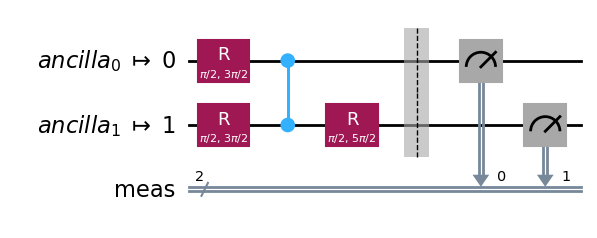

Mitigated counts: {'10': 6, '01': 20, '00': 989, '11': 1030}


In [2]:
# Create a Bell state circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Transpile for specific qubits
qubits = ["QB9", "QB17"]
qubit_indices = [backend.qubit_name_to_index(q) for q in qubits]
qc_transpiled = transpile(qc, backend=backend, initial_layout=qubit_indices)

display(qc_transpiled.draw(output="mpl"))

# Run with automatic mitigation!
shots = 2048
job = mitigated_backend.run(qc_transpiled, shots=shots)
mitigated_counts = job.result().get_counts()

print("Mitigated counts:", mitigated_counts)

In [3]:
print(job.result().results[0].header)

raw_counts = job.result().results[0].header["fiqci_ems"]["raw_counts"]

print(raw_counts)

{'creg_sizes': [['meas', 2]], 'global_phase': 0.0, 'memory_slots': 2, 'n_qubits': 54, 'name': 'circuit-19877', 'qreg_sizes': [['q', 2], ['ancilla', 52]], 'metadata': {}, 'fiqci_ems': {'mitigation_level': 1, 'mitigation_method': 'M3', 'calibration_shots': 2048, 'raw_counts': {'01': 97, '10': 89, '00': 907, '11': 955}}}
{'01': 97, '10': 89, '00': 907, '11': 955}


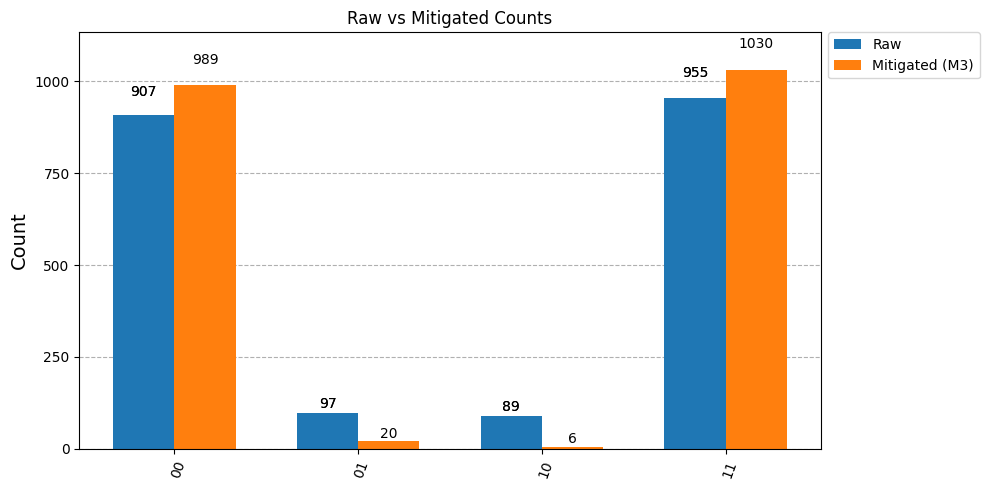

In [4]:
from qiskit.visualization import plot_histogram

# Compare raw vs mitigated results
plot_histogram(
	[raw_counts, mitigated_counts],
	legend=["Raw", "Mitigated (M3)"],
	title="Raw vs Mitigated Counts",
	bar_labels=True,
	figsize=(10, 5),
)

In [5]:
from fiqci.ems.mitigators.rem import M3IQM
from fiqci.ems.utils import probabilities_to_counts

# Initialize M3 mitigator
m3_mitigator = M3IQM(backend)

# Calibrate for specific qubits
m3_mitigator.cals_from_system(qubits=qubit_indices, shots=2048, method="balanced")

# Inspect calibration matrices
print("QB26 (index", qubit_indices[0], ") calibration matrix:")
print(m3_mitigator.cals_to_matrices()[qubit_indices[0]])
print("\nQB27 (index", qubit_indices[1], ") calibration matrix:")
print(m3_mitigator.cals_to_matrices()[qubit_indices[1]])

QB26 (index 8 ) calibration matrix:


[[0.9511719  0.04394531]
 [0.04882812 0.9560547 ]]

QB27 (index 16 ) calibration matrix:
[[0.9609375  0.04785156]
 [0.0390625  0.95214844]]


In [6]:
# Run circuit and get raw counts
raw_counts_manual = backend.run(qc_transpiled, shots=shots).result().get_counts()

# Apply M3 correction manually
quasi_dist = m3_mitigator.apply_correction(raw_counts_manual, qubits=qubit_indices, return_mitigation_overhead=True)

# Get expectation value and standard deviation
expval, stddev = quasi_dist.expval_and_stddev()
print(f"Expectation value: {expval:.4f} ± {stddev:.4f}")

# Convert to nearest probability distribution
mitigated_probs = quasi_dist.nearest_probability_distribution()
mitigated_counts_manual = probabilities_to_counts(mitigated_probs, shots)

print("\nRaw counts:", raw_counts_manual)
print("Mitigated counts:", mitigated_counts_manual[0])

Expectation value: 0.9122 ± 0.0270

Raw counts: {'01': 115, '11': 897, '10': 135, '00': 901}
Mitigated counts: {'01': 26, '10': 63, '11': 979, '00': 979}


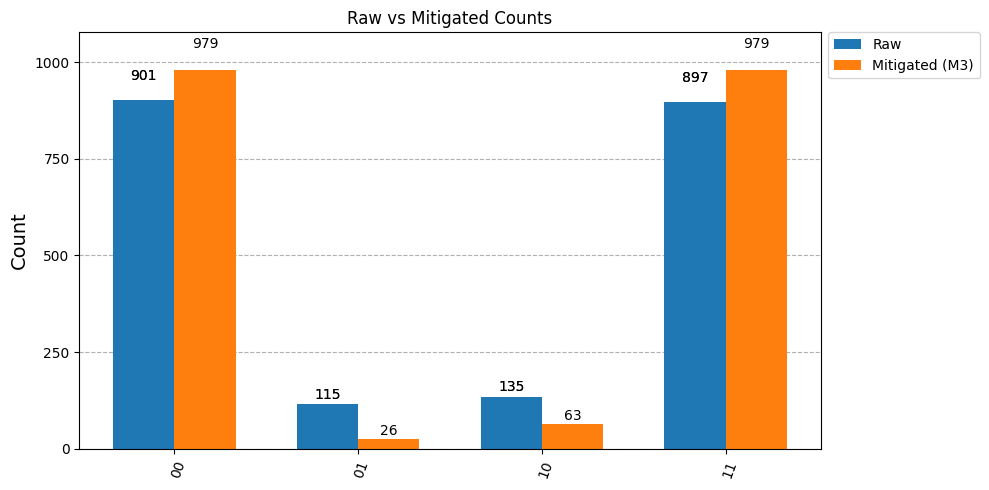

In [7]:
from qiskit.visualization import plot_histogram

# Compare raw vs mitigated results
plot_histogram(
	[raw_counts_manual, mitigated_counts_manual[0]],
	legend=["Raw", "Mitigated (M3)"],
	title="Raw vs Mitigated Counts",
	bar_labels=True,
	figsize=(10, 5),
)